## 04. 세입 예산편성현황 데이터 분석 시각화

인덱스 재구성(inplace=True -> 원본 데이터 자체 수정)
- `.reset_index(inplace=True)`

마이너스 기호 깨지는 현상 방지
- `plt.rc('axes', unicode_minus=False)`

교차 빈도 분석
- 데이터프레임`.pivot_table(data='데이터컬럼', index='인덱스컬럼', columns='교차분석 컬럼', aggfunc='data 적용함수')`

히트맵을 활용한 교차 빈도 분석
- `sns.heatmap(수입관항_피봇, annot=True, fmt='.0f', cmap='RdYlGn_r',linewidths=0.1,linecolor='grey')`


In [17]:
!pip3 install pandas
!pip3 install matplotlib.pyplot 
!pip3 install seaborn

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib 

# 과학적 표기법 해제
pd.options.display.float_format = '{:.0f}'.format

세입예산편성_DF = pd.read_csv("Practice Data/세입_예산편성현황_2024.csv")
세출예산편성_DF = pd.read_csv("Practice Data/세출_예산편성현황_2024.csv")

# 컬럼명 변경
세입예산편성_DF.rename(columns = {'정부안금액(천원)' : '정부안금액', '국회확정금액(천원)':'국회확정금액'}, inplace=True)

# 컴마 제거, 문자열 데이터 숫자 변환(정부안금액/국회확정금액)
세입예산편성_DF.정부안금액 = 세입예산편성_DF.정부안금액.str.replace(',', '')
세입예산편성_DF.국회확정금액 = 세입예산편성_DF.국회확정금액.str.replace(',', '')

세입예산편성_DF.정부안금액 = pd.to_numeric(세입예산편성_DF.정부안금액)
세입예산편성_DF.국회확정금액 = pd.to_numeric(세입예산편성_DF.국회확정금액)


# 소관명 빈도 분석 및 빈도 비율 분석
pd.DataFrame(세입예산편성_DF.소관명.value_counts())

# 위에서 과학적 표기법으로 정수형태로 반환하였기에, 특정 코드에서만 임시로 보이게 설정해줘야함.
# 이 블록 안에서만 소수점 4자리로 출력함
with pd.option_context('display.float_format','{:.4}'.format):  
    pd.DataFrame(세입예산편성_DF.소관명.value_counts(normalize=True))

# 소관명별 정부안금액 합계
소관별_정부안금액 = pd.DataFrame(세입예산편성_DF.groupby('소관명')['정부안금액'].sum())
소관별_정부안금액.sort_values('정부안금액', ascending=False)

# 소관명별 국회확정금액 합계
소관별_국회확정금액 = pd.DataFrame(세입예산편성_DF.groupby('소관명')['국회확정금액'].sum())
소관별_국회확정금액.sort_values('국회확정금액', ascending=False)

# 정부안금액 및 국회확정금액 차이 분석 + new column 생성
세입예산편성_DF['차이금액'] = 세입예산편성_DF.정부안금액 - 세입예산편성_DF.국회확정금액

# 수입목명별 세입 축소 빈도 분석
pd.DataFrame(세입예산편성_DF[세입예산편성_DF.차이금액 > 0].수입목명.value_counts())
pd.DataFrame(세입예산편성_DF[세입예산편성_DF.차이금액 < 0].수입목명.value_counts())

# 소관명별 정부안금액 및 국회확정금액 차이 분석
소관별_차이금액 = pd.DataFrame(세입예산편성_DF.groupby('소관명')['차이금액'].sum())

# 세입과목 분류표(한국재정정보원, 2024 회계기금운용기준)

국세수입 = ['내국세', '관세','교통·에너지·환경세','교육세', '농어촌특별세', '종합부동산세']
자체수입 = ['기업특별회계영업수입', '사회보장기여금','재산수입','경상이전수입','재화및용역판매수입',
'수입대체경비수입','관유물매각대','융자및전대차관원금회수']
정부내부수입및기타 = ['정부내부수입및기타','전년도이월금','세계잉여금','차입금및여유자금회수']
여유자금회수 = ['유가증권매각대','정부예금회수']

def 세입과목분류(row):
    if row.수입관명 in 국세수입:
        return '국세수입'
    elif row.수입관명 in 자체수입:
        return '자체수입'
    elif row.수입관명 in 정부내부수입및기타:
        if row.수입목명 == '기타민간예수금':
            return '여유자금회수'
        elif row.수입목명 in 여유자금회수:
            return '여유자금회수'
        else:
            return '정부내부수입및기타'
    
# 세입과목 분류표 적용
세입예산편성_DF['세입과목분류'] = 세입예산편성_DF.apply(세입과목분류,axis=1)

# 과목분류별 count
세입예산편성_DF.세입과목분류.value_counts()

# 세입과목분류별 국회확정금액 집계 및 억단위 변환
세입유형별세입 = pd.DataFrame(세입예산편성_DF.groupby('세입과목분류')['국회확정금액'].sum()/100000)
세입유형별세입.국회확정금액 = round(세입유형별세입.국회확정금액)

#출력순서 지정
세입유형별세입.iloc[[0,2,3,1],:]

,국회확정금액
세입과목분류,
국세수입,3673140
자체수입,2599724
정부내부수입및기타,9241362
여유자금회수,218848


/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_28043/4217266864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='소관명', data=세입예산편성_DF,palette='hls')


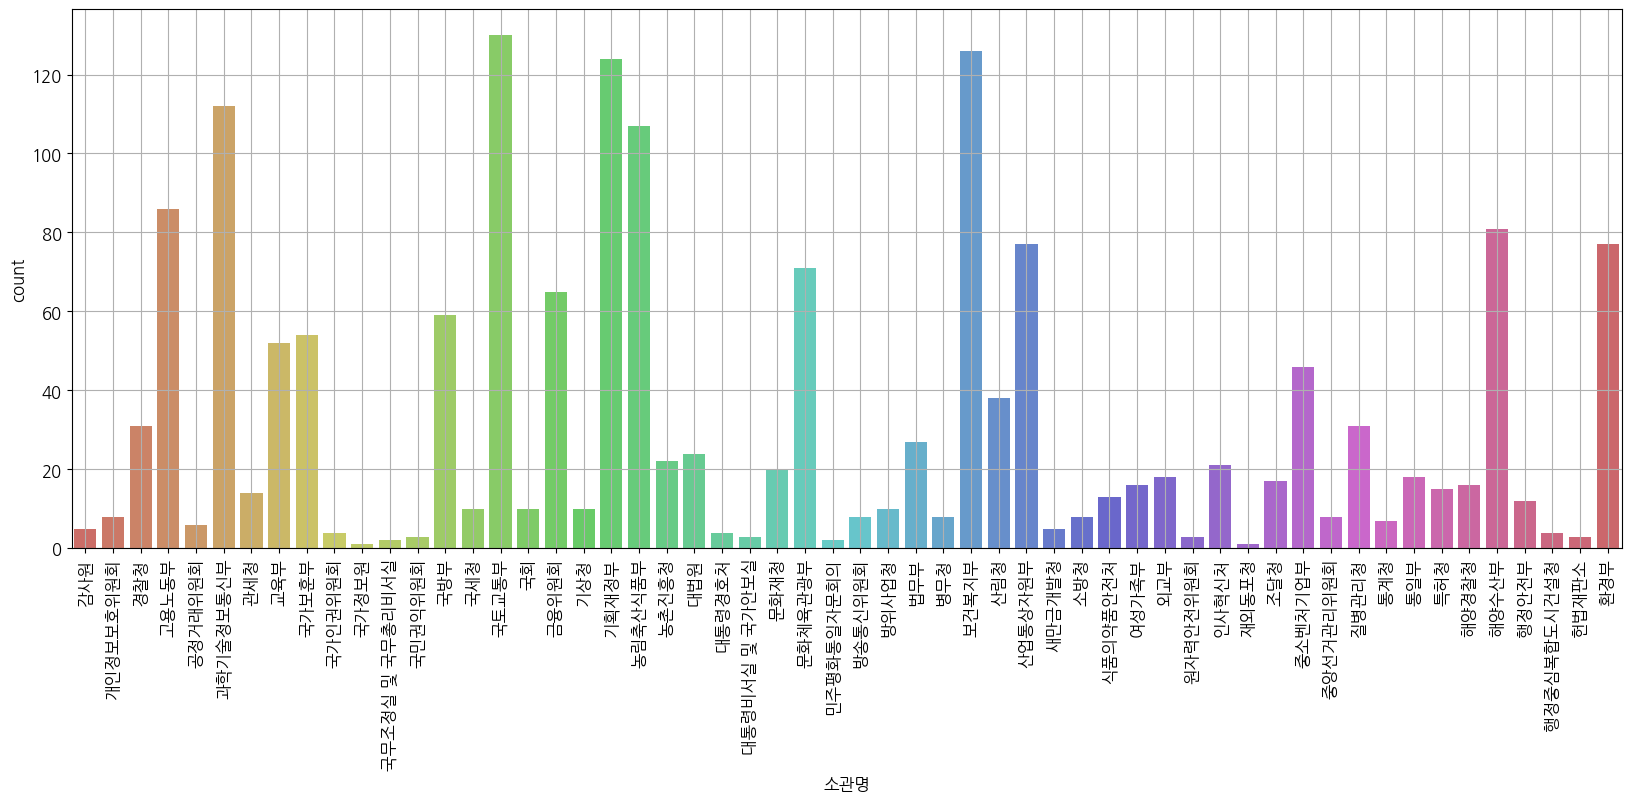

In [19]:
plt.rcParams['font.size']=12

plt.figure(figsize=(20,7))
plt.xticks(rotation=90)
sns.countplot(x='소관명', data=세입예산편성_DF,palette='hls')
plt.grid()
plt.show()

In [20]:
#인덱스 재구성
소관별_차이금액.reset_index(inplace=True)
소관별_차이금액[:10]

,소관명,차이금액
0,감사원,0
1,개인정보보호위원회,0
2,경찰청,-1845000
3,고용노동부,0
4,공정거래위원회,0
5,과학기술정보통신부,472000
6,관세청,-1199000
7,교육부,-184964000
8,국가보훈부,3704000
9,국가인권위원회,0


In [21]:
#차이금액 백만원 단위 변환
소관별_차이금액['차이금액_백만'] = round(소관별_차이금액.차이금액/1000)
소관별_차이금액[:10]

,소관명,차이금액,차이금액_백만
0,감사원,0,0
1,개인정보보호위원회,0,0
2,경찰청,-1845000,-1845
3,고용노동부,0,0
4,공정거래위원회,0,0
5,과학기술정보통신부,472000,472
6,관세청,-1199000,-1199
7,교육부,-184964000,-184964
8,국가보훈부,3704000,3704
9,국가인권위원회,0,0


/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_28043/3470049836.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 > 0], palette='hls')


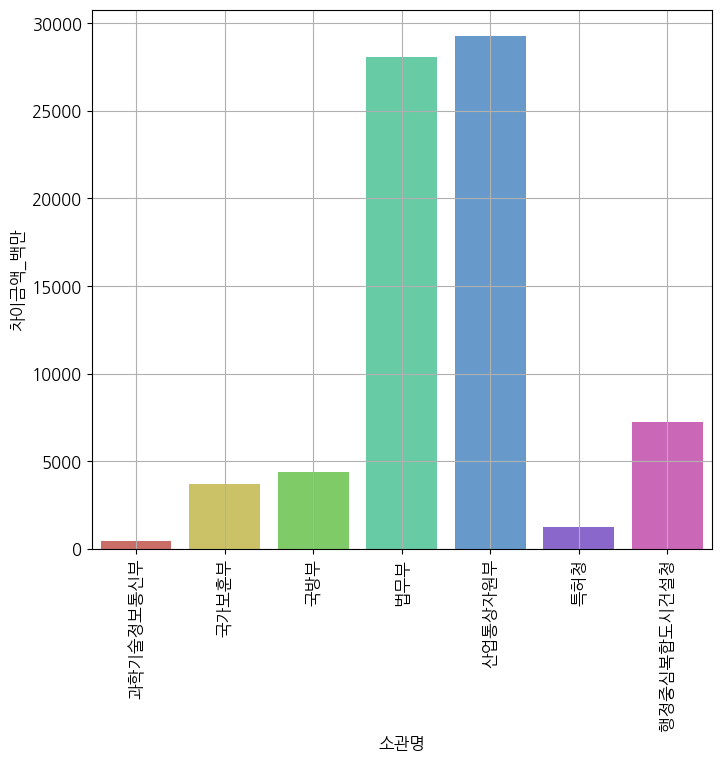

In [22]:
#정부안금액이 큰(국회에서 세입 축소된)소관명별 금액
plt.figure(figsize=(8,7))
plt.xticks(rotation=90)
sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 > 0], palette='hls')
plt.grid()
plt.show()

/var/folders/pj/8ypmm1dx3971ch18spgwm3qc0000gn/T/ipykernel_28043/532904017.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 < 0], palette='hls')


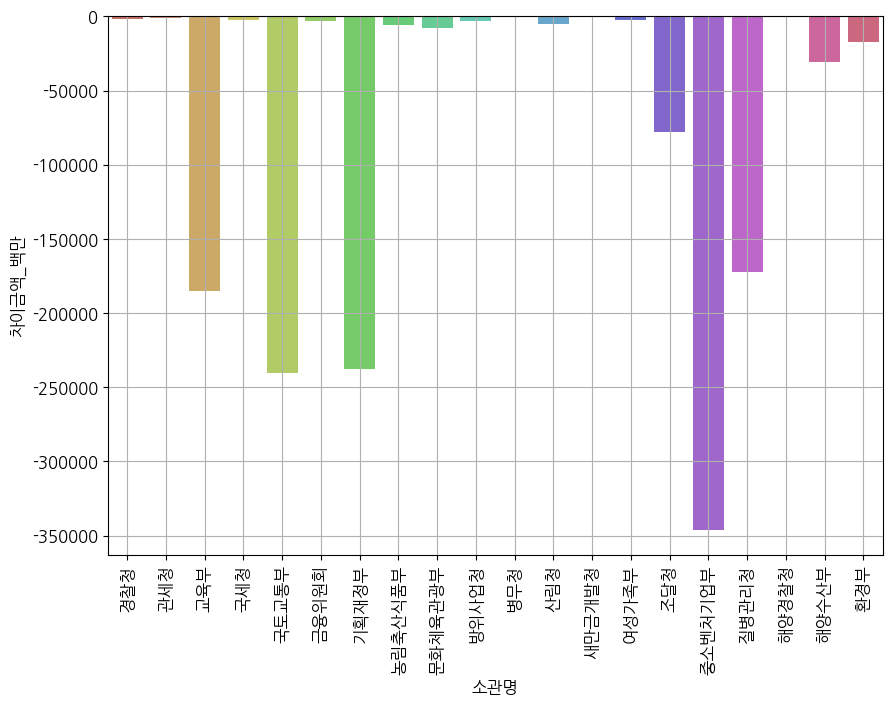

In [25]:
#국회확정금액이 큰(국회에서 세입 확대된)소관명별 금액
plt.figure(figsize=(10,7))
plt.xticks(rotation=90)
plt.rc('axes',unicode_minus=False)
sns.barplot(x='소관명',y='차이금액_백만',data=소관별_차이금액[소관별_차이금액.차이금액_백만 < 0], palette='hls')
plt.grid()
plt.show()

In [26]:
# 수입관명과 수입항명 교차 빈도 분석

수입관항_피봇 = 세입예산편성_DF.pivot_table('No.',index='수입관명',columns='수입항명', aggfunc='count')
수입관항_피봇[:5]

수입항명,가산금,개별소비세,고정자산매각대,관세,관유물대여료,교도소수입,교육세,교통·에너지·환경세,국공채수입,기타,...,정부예금회수,정부출자수입,정부출자주식매각대,조달사업수입,종합부동산세,주세,증권거래세,책임운영기관사업수입,토지및무형자산매각대,항공항만및용수수입
수입관명,,,,,,,,,,,,,,,,,,,,,
경상이전수입,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
관세,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
관유물매각대,NaN,NaN,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27,NaN
교육세,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
교통·에너지·환경세,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='수입항명', ylabel='수입관명'>

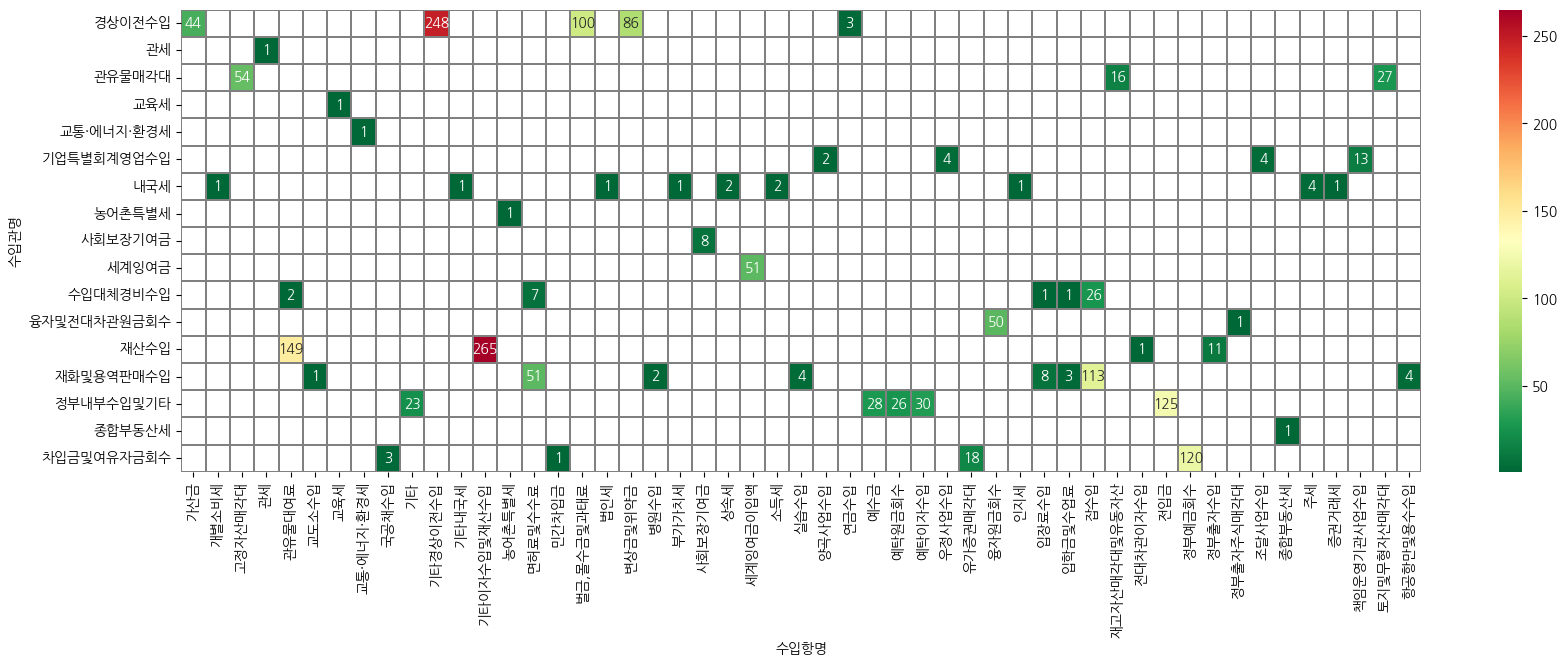

In [ ]:
# HeadMap을 이용한 수항관명 및 수입항명 교차 빈도 분석
plt.rcParams['font.size']=10
plt.figure(figsize=(20,6))
sns.heatmap(수입관항_피봇, annot=True, fmt='.0f', cmap='RdYlGn_r',linewidths=0.1,linecolor='grey')

In [29]:
# 소관명별 수입항명별 세입축소 교차 분석

세입예산편성_금액축소 = 세입예산편성_DF[세입예산편성_DF.차이금액 > 0].pivot_table('차이금액', index='소관명', columns='수입항명',aggfunc='sum')
세입예산편성_금액축소

수입항명,관유물대여료,국공채수입,기타이자수입및재산수입,면허료및수수료,민간차입금,소득세,예수금,예탁이자수입,입장료수입,전입금
소관명,,,,,,,,,,
과학기술정보통신부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12500000,NaN,NaN
교육부,NaN,NaN,NaN,NaN,NaN,NaN,2040000,NaN,NaN,NaN
국가보훈부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3704000
국방부,NaN,NaN,NaN,NaN,NaN,NaN,19411000,NaN,NaN,NaN
국토교통부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,166142000
기획재정부,NaN,403683000,111202000,NaN,NaN,64500000,163077000,4881000,NaN,4751000
농림축산식품부,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,140093000
문화재청,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3000000,NaN
문화체육관광부,4777000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='수입항명', ylabel='소관명'>

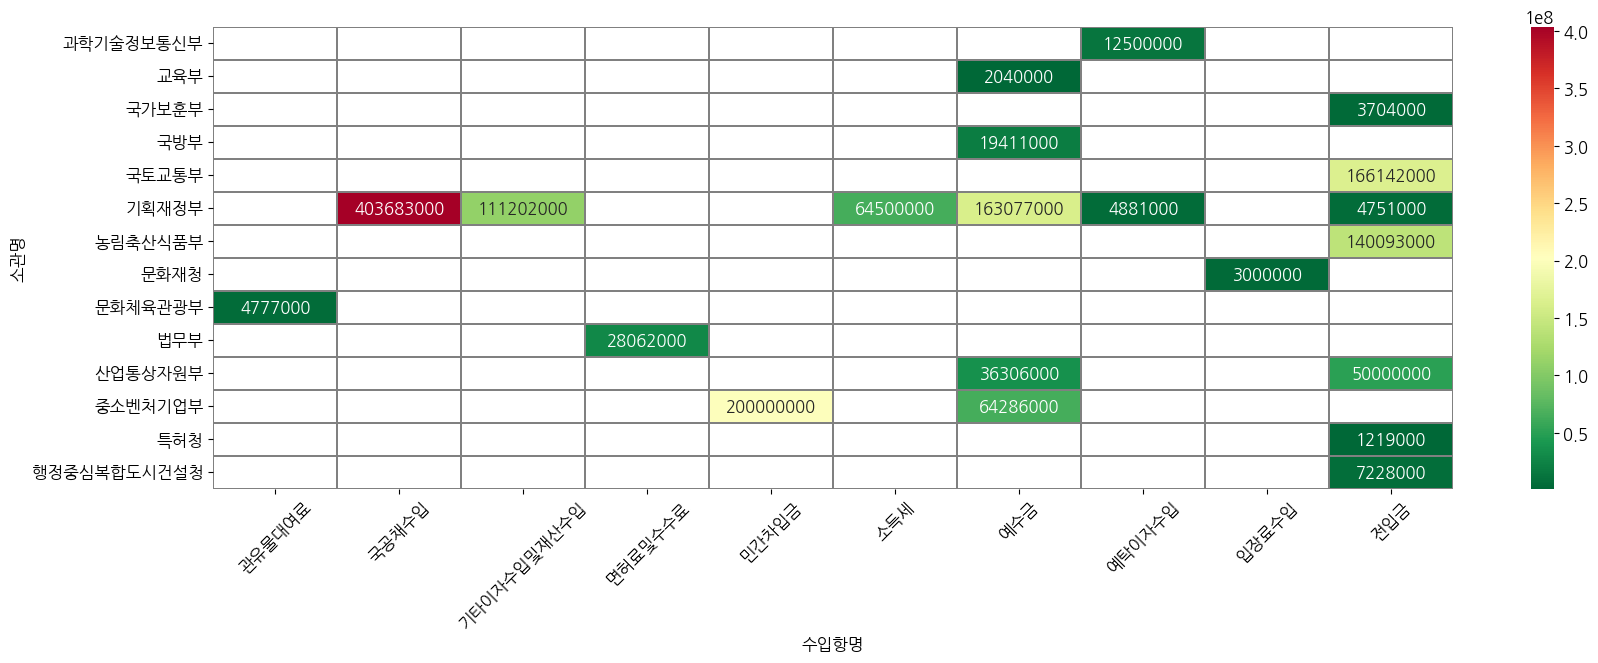

In [30]:
#Heat Map을 이용한 소관명별 수입항명별 세입축소 교차분석

plt.rcParams['font.size']=12
f, ax = plt.subplots(figsize=(20,6))
plt.xticks(rotation=45)
sns.heatmap(세입예산편성_금액축소, annot=True, fmt='.0f', cmap='RdYlGn_r',linewidths=0.1,linecolor='grey')

<Axes: xlabel='수입항명', ylabel='소관명'>

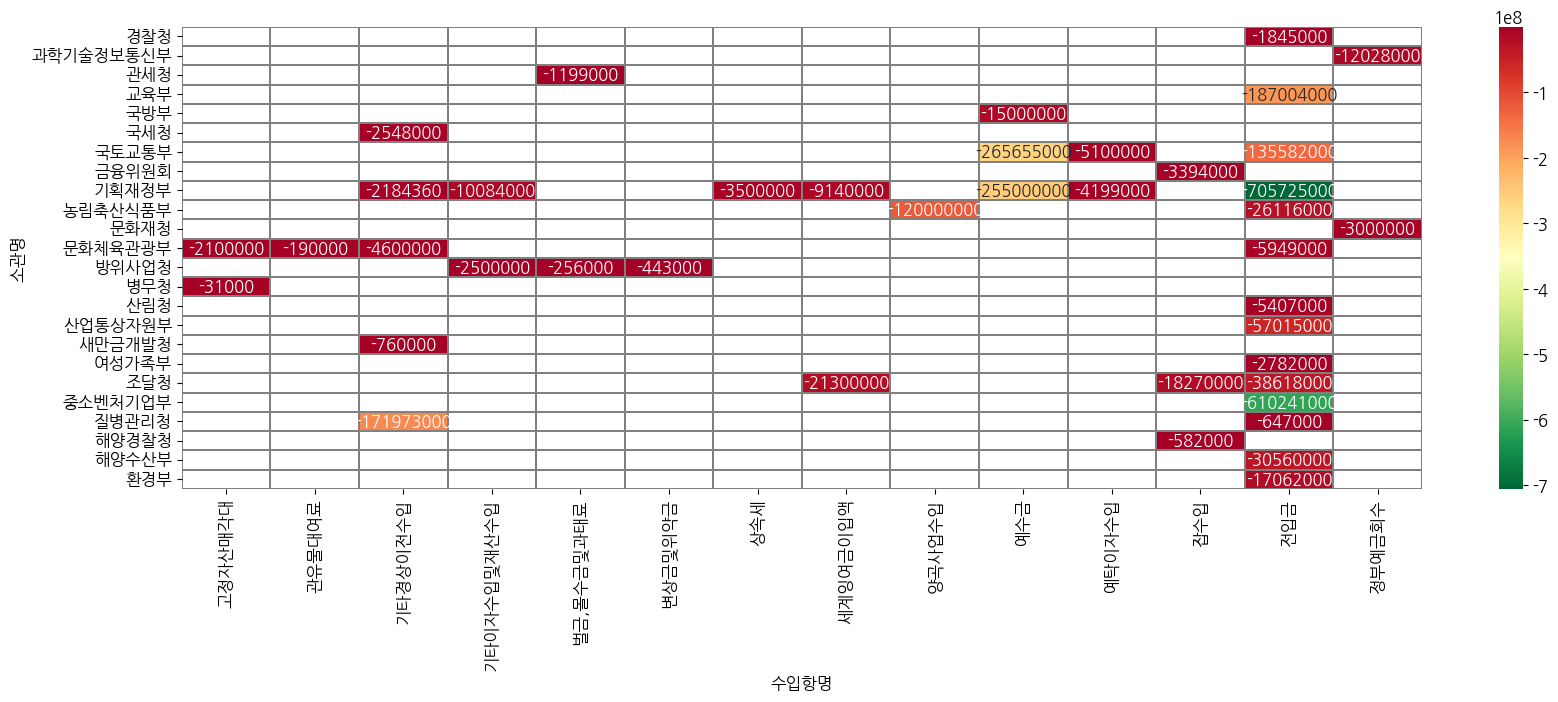

In [31]:
# 소관명별 수입항명별 세입확대 교차 분석

세입예산편성_금액확대 = 세입예산편성_DF[세입예산편성_DF.차이금액 < 0].pivot_table('차이금액', index='소관명', columns='수입항명',aggfunc='sum')

#Heat Map을 이용한 소관명별 수입항명별 세입축소 교차분석

plt.rcParams['font.size']=12
f, ax = plt.subplots(figsize=(20,6))
plt.xticks(rotation=45)
sns.heatmap(세입예산편성_금액확대, annot=True, fmt='.0f', cmap='RdYlGn_r',linewidths=0.1,linecolor='grey')